## 1) Importação de bibliotecas e configuração de exibição

Nesta etapa importamos as bibliotecas principais (`pandas` e `numpy`) e ajustamos opções de visualização para facilitar a leitura das tabelas no notebook.

In [67]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 2) Carregamento do dataset

Aqui lemos o arquivo `synthetic_medical_triage.csv` para a variável `df` e mostramos as primeiras linhas para validar se os dados foram carregados corretamente.  
Fonte: https://www.kaggle.com/datasets/ilkeryildiz/emergency-service-triage-application/data

In [68]:
df = pd.read_csv("../data/synthetic_medical_triage.csv")

df.head()

,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0


## 3) Dimensão e colunas do dataset

Calculamos a quantidade de linhas e colunas (`shape`) e listamos os nomes das colunas para entender a estrutura geral dos dados.

In [69]:
n_linhas, n_colunas = df.shape

print(f"Quantidade de linhas: {n_linhas}")
print(f"Quantidade de colunas: {n_colunas}")
print("\nColunas do dataset:")
print(df.columns.tolist())

Quantidade de linhas: 18000
Quantidade de colunas: 10

Colunas do dataset:
['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation', 'body_temperature', 'pain_level', 'chronic_disease_count', 'previous_er_visits', 'arrival_mode', 'triage_level']


## 4) Tipos de dados e campos preenchidos

Usamos `df.info()` para verificar tipos das variáveis, quantidade de valores não nulos e consumo de memória.

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      18000 non-null  float64
 1   heart_rate               18000 non-null  float64
 2   systolic_blood_pressure  18000 non-null  float64
 3   oxygen_saturation        18000 non-null  float64
 4   body_temperature         18000 non-null  float64
 5   pain_level               18000 non-null  int64  
 6   chronic_disease_count    18000 non-null  int64  
 7   previous_er_visits       18000 non-null  int64  
 8   arrival_mode             18000 non-null  str    
 9   triage_level             18000 non-null  int64  
dtypes: float64(5), int64(4), str(1)
memory usage: 1.4 MB


## 5) Estatísticas descritivas

Geramos um resumo estatístico das variáveis numéricas (média, desvio padrão, mínimos, máximos e quartis) para identificar escala e dispersão dos dados.

In [71]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,18000.0,44.716244,19.101056,0.00,31.20,44.00,57.50,95.00
heart_rate,18000.0,83.292322,16.964405,33.40,71.50,81.60,93.20,152.30
systolic_blood_pressure,18000.0,128.072739,18.813277,65.80,114.90,126.90,139.90,219.70
oxygen_saturation,18000.0,96.085183,3.330830,79.50,94.30,96.60,98.70,100.00
body_temperature,18000.0,37.224236,0.914978,34.47,36.58,37.12,37.77,41.13
pain_level,18000.0,3.402111,2.039249,1.00,2.00,3.00,5.00,10.00
chronic_disease_count,18000.0,1.072611,1.312204,0.00,0.00,1.00,2.00,10.00
previous_er_visits,18000.0,1.265056,1.454887,0.00,0.00,1.00,2.00,11.00
triage_level,18000.0,0.697722,0.898923,0.00,0.00,0.00,1.00,3.00


## 6) Análise de valores ausentes

Contamos valores nulos por coluna e o total de ausências no dataset para avaliar necessidade de tratamento antes da modelagem.

In [72]:
missing = df.isnull().sum().sort_values(ascending=False)

display(missing.to_frame("qtd_ausentes"))
print(f"\nTotal de valores ausentes no dataset: {missing.sum()}")

,qtd_ausentes
age,0
heart_rate,0
systolic_blood_pressure,0
oxygen_saturation,0
body_temperature,0
pain_level,0
chronic_disease_count,0
previous_er_visits,0
arrival_mode,0
triage_level,0



Total de valores ausentes no dataset: 0


## 7) Cardinalidade por coluna

Calculamos quantos valores únicos existem em cada variável. Isso ajuda a distinguir variáveis contínuas, categóricas e possíveis colunas de alta cardinalidade.

In [33]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores unicos")

age: 944 valores unicos
heart_rate: 985 valores unicos
systolic_blood_pressure: 1072 valores unicos
oxygen_saturation: 185 valores unicos
body_temperature: 560 valores unicos
pain_level: 10 valores unicos
chronic_disease_count: 11 valores unicos
previous_er_visits: 12 valores unicos
arrival_mode: 3 valores unicos
triage_level: 4 valores unicos


## 9) Heatmap de correlação com a variável target (`triage_level`)

Nesta etapa calculamos a matriz de correlação somente com as colunas numéricas e geramos um heatmap com `matplotlib` para visualizar a força e o sinal das correlações em relação à variável alvo.

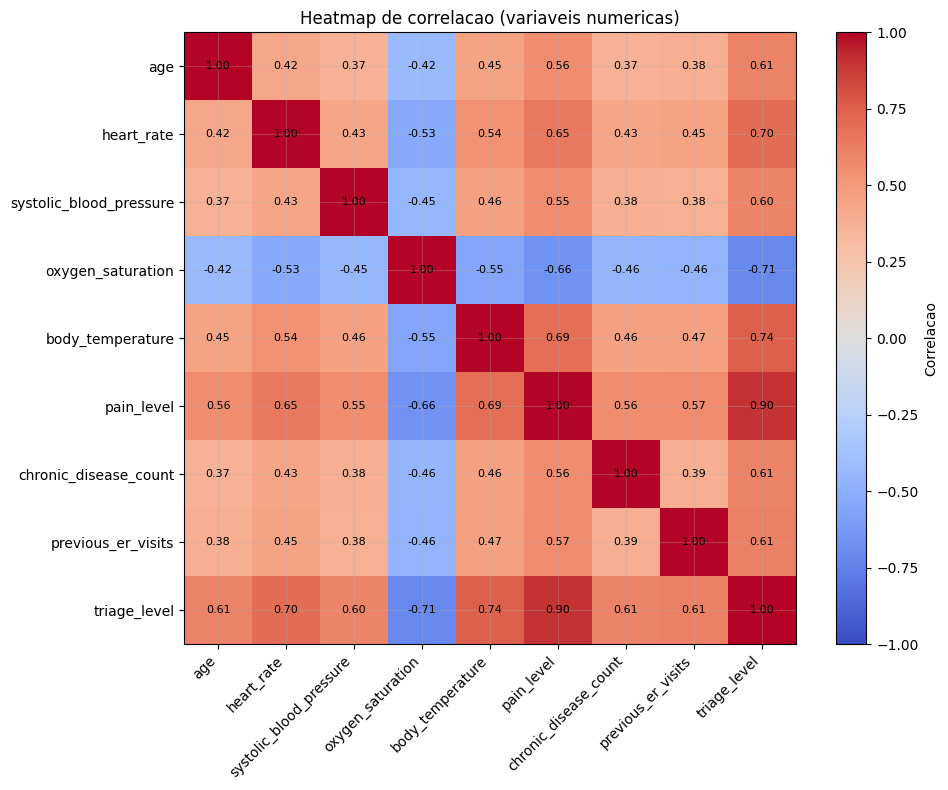

Correlacoes com triage_level (ordem decrescente):


,correlacao_com_target
pain_level,0.901481
body_temperature,0.744840
heart_rate,0.698281
previous_er_visits,0.612760
age,0.607368
chronic_disease_count,0.605720
systolic_blood_pressure,0.600663
oxygen_saturation,-0.714006


In [73]:
import matplotlib.pyplot as plt

TARGET = "triage_level"

# Correlacao apenas entre variaveis numericas
corr_matrix = df.select_dtypes(include=["number"]).corr()

# Reordenar para deixar target ao final (facilita leitura visual)
ordered_cols = [c for c in corr_matrix.columns if c != TARGET] + [TARGET]
corr_matrix = corr_matrix.loc[ordered_cols, ordered_cols]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

# Eixos e labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Heatmap de correlacao (variaveis numericas)")

# Barra de cor
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlacao")

# Inserir valores de correlacao nas celulas
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

# Tabela ordenada de correlacao com a variavel alvo
corr_target = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlacoes com triage_level (ordem decrescente):")
display(corr_target.to_frame("correlacao_com_target"))

## 10) Gráficos exploratórios com matplotlib

Nesta seção montamos as figuras **por partes**. Antes de cada gráfico há um bloco em markdown explicando **o que** o gráfico mostra e **por que** ele é útil no contexto de triagem médica. A primeira célula de código só importa o `matplotlib` e define um estilo básico (tamanho da figura e grade leve).

In [74]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

### 10.1) Distribuição dos níveis de triagem (`triage_level`)

O campo `triage_level` é a **classe alvo**: representa a gravidade atribuída na triagem (valores de 0 a 3 neste dataset). O gráfico de barras abaixo conta **quantos casos** existem em cada nível.

Isso é importante para avaliar o **balanceamento das classes**.
No dataset escolhido temos muitos exemplos de "casos leves"; se fossem utilizadas métricas de acurácia, teríamos uma análise muito propensa a erro.

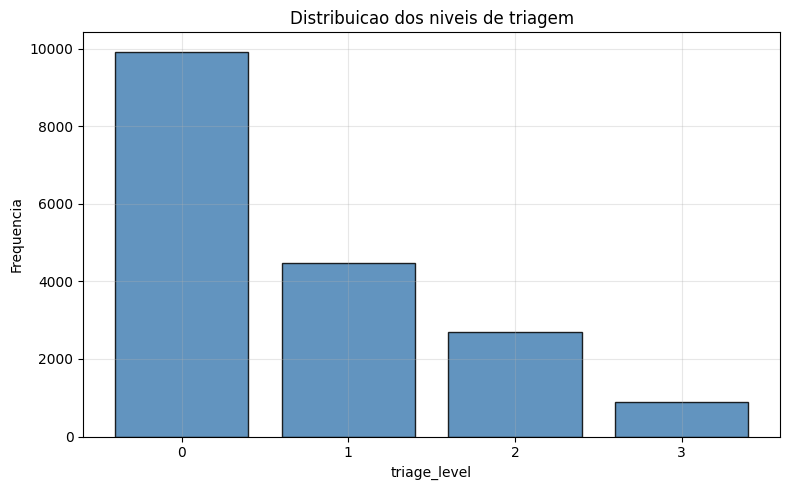

In [75]:
fig, ax = plt.subplots(figsize=(8, 5))
triage_counts = df["triage_level"].value_counts().sort_index()
ax.bar(
    triage_counts.index.astype(str),
    triage_counts.values,
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
)
ax.set_title("Distribuicao dos niveis de triagem")
ax.set_xlabel("triage_level")
ax.set_ylabel("Frequencia")
plt.tight_layout()
plt.show()

### 10.2) Modo de chegada (`arrival_mode`)

Este gráfico mostra **como o paciente chegou** ao atendimento (por exemplo `walk_in`, `ambulance` ou `wheelchair`). O tamanho de cada barra é o número de registros naquela categoria.

É útil porque o **canal de chegada** pode estar ligado à gravidade: chegadas por ambulância, por exemplo, costumam concentrar casos mais urgentes. Isso ajuda a contextualizar o dataset antes de modelar ou de comparar grupos.

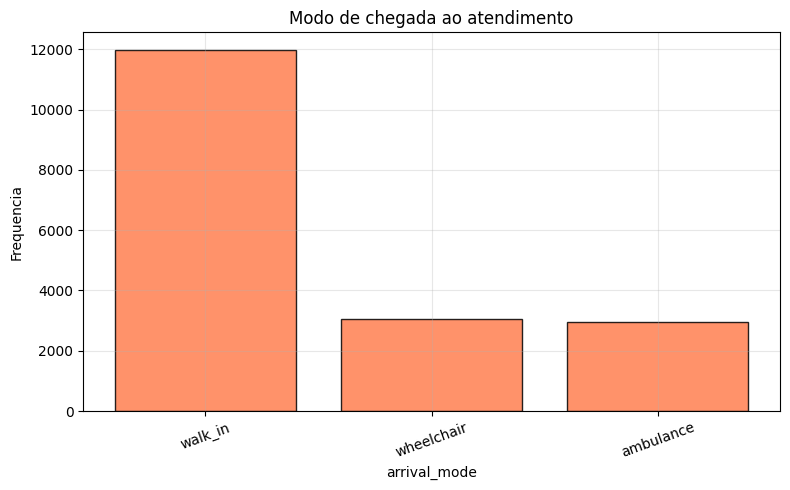

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
arrival = df["arrival_mode"].value_counts()
ax.bar(arrival.index, arrival.values, color="coral", edgecolor="black", alpha=0.85)
ax.set_title("Modo de chegada ao atendimento")
ax.set_xlabel("arrival_mode")
ax.set_ylabel("Frequencia")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### 10.3) Distribuicao etaria (`age`)

O **histograma** resume como as idades se distribuem no conjunto: onde ha mais concentracao e se existem caudas (muito jovem ou muito idoso).

Serve para verificar se o dataset **representa bem varias faixas etarias**. Um recorte muito enviesado em idade pode afetar a interpretacao de risco e a generalizacao de qualquer modelo de triagem treinado nesses dados.

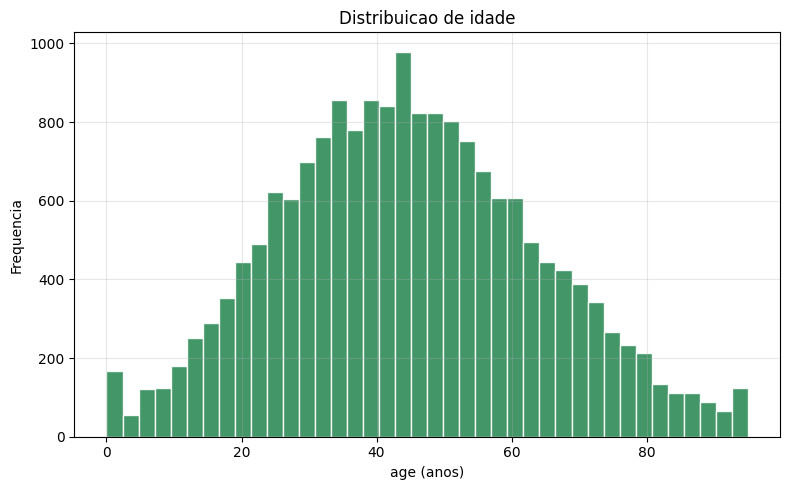

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["age"], bins=40, color="seagreen", edgecolor="white", alpha=0.9)
ax.set_title("Distribuicao de idade")
ax.set_xlabel("age (anos)")
ax.set_ylabel("Frequencia")
plt.tight_layout()
plt.show()

### 10.4) Distribuicao do nivel de dor (`pain_level`)

A **escala de dor** e um dos sinais subjetivos mais usados na triagem. O histograma indica com que frequencia aparecem cada valor de `pain_level` no dataset.

Comparar esta forma com o `triage_level` (e com o heatmap de correlacao ja visto) ajuda a entender se dor mais alta **acompanha** niveis de gravidade mais altos de forma consistente nos dados.

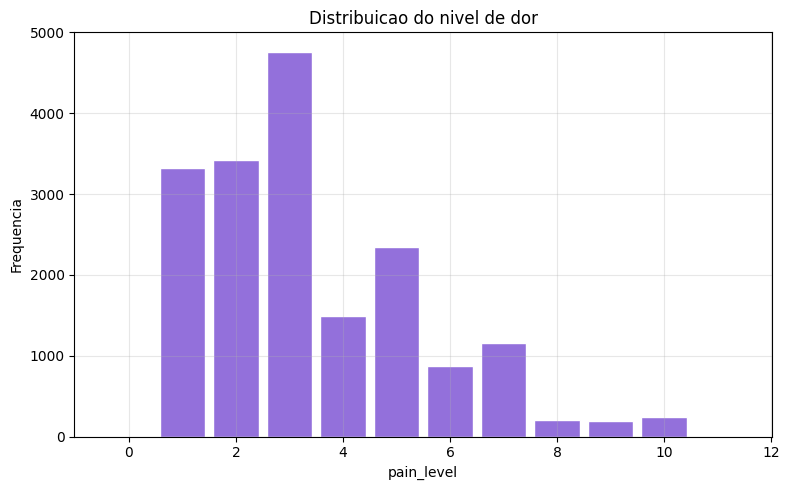

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    df["pain_level"],
    bins=range(0, 13),
    align="left",
    rwidth=0.85,
    color="mediumpurple",
    edgecolor="white",
)
ax.set_title("Distribuicao do nivel de dor")
ax.set_xlabel("pain_level")
ax.set_ylabel("Frequencia")
plt.tight_layout()
plt.show()

### 10.5) Sinais vitais por nivel de triagem (boxplot)

Aqui comparamos **tres medidas numericas** entre grupos definidos pelo `triage_level`: frequencia cardiaca, saturacao de oxigenio e temperatura corporal.

Cada **boxplot** resume mediana, quartis e valores extremos daquele sinal **dentro de cada nivel de triagem**. Assim vemos nao so tendencias de media, mas dispersao e possiveis outliers — um complemento util ao heatmap de correlacao, que so captura relacao linear entre numeros.

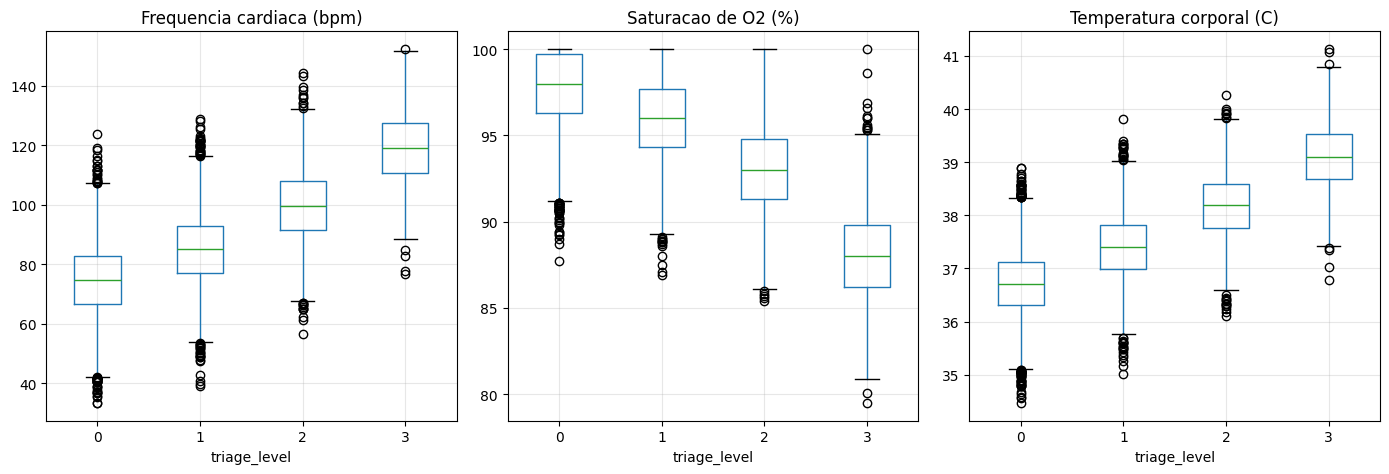

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
box_cols = ["heart_rate", "oxygen_saturation", "body_temperature"]
titles_pt = {
    "heart_rate": "Frequencia cardiaca (bpm)",
    "oxygen_saturation": "Saturacao de O2 (%)",
    "body_temperature": "Temperatura corporal (C)",
}
for ax, col in zip(axes, box_cols):
    df.boxplot(column=col, by="triage_level", ax=ax)
    ax.set_title(titles_pt[col])
    ax.set_xlabel("triage_level")
plt.suptitle("")
plt.tight_layout()
plt.show()

### 10.6) Dor versus frequencia cardiaca (grafico de dispersao)

Cada **ponto** e um paciente: no eixo horizontal esta o `pain_level` e na vertical a `heart_rate`. A **cor** do ponto indica o `triage_level`.

Usamos transparencia (`alpha`) para onde ha **muitos pontos sobrepostos** parecer mais “denso”. O objetivo e visualizar, de forma conjunta, se combinacoes de dor alta e FC elevada aparecem mais nos niveis de triagem mais graves — algo que a analise de correlacao ja sugere, mas aqui fica **geometricamente** visivel.

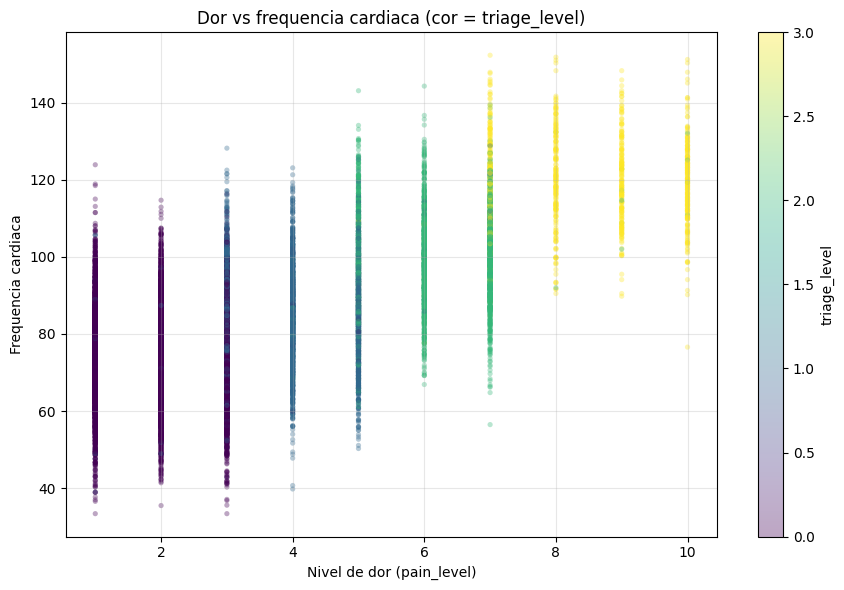

In [76]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    df["pain_level"],
    df["heart_rate"],
    c=df["triage_level"],
    cmap="viridis",
    alpha=0.35,
    s=14,
    edgecolors="none",
)
ax.set_xlabel("Nivel de dor (pain_level)")
ax.set_ylabel("Frequencia cardiaca")
ax.set_title("Dor vs frequencia cardiaca (cor = triage_level)")
cb = fig.colorbar(sc, ax=ax)
cb.set_label("triage_level")
plt.tight_layout()
plt.show()

### 10.7) Medias de sinais vitais por nivel de triagem (barras)

Por fim, tres graficos de barras lado a lado mostram a **media** de frequencia cardiaca, pressao arterial sistolica e saturacao de oxigenio **para cada** `triage_level`.

Mantemos **um subplot por variavel** porque as unidades e faixas tipicas sao diferentes: juntar tudo num unico eixo distorceria a comparacao. A leitura desejada e: “ao subir o nivel de triagem, essas medias tendem a subir ou cair?” — em linha com o que ja observamos nos boxplots e na correlacao.

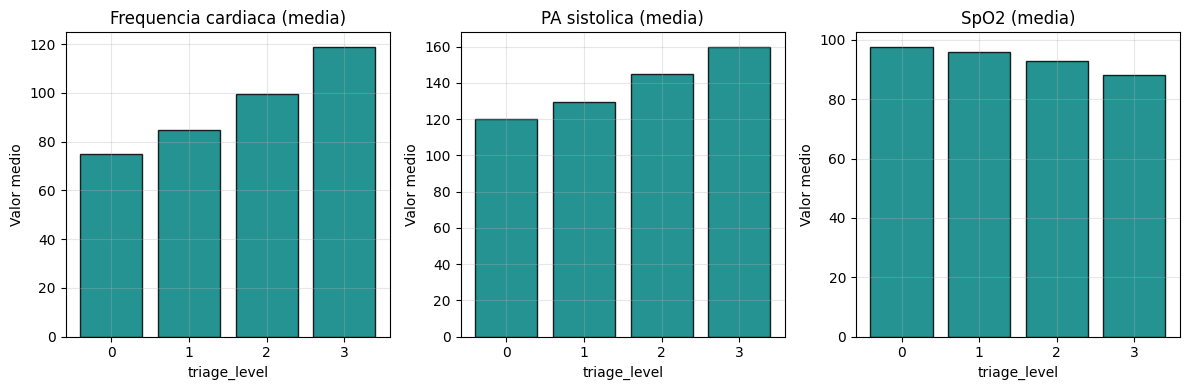

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
bar_specs = [
    ("heart_rate", "Frequencia cardiaca (media)"),
    ("systolic_blood_pressure", "PA sistolica (media)"),
    ("oxygen_saturation", "SpO2 (media)"),
]
for ax, (col, title) in zip(axes, bar_specs):
    m = df.groupby("triage_level")[col].mean()
    ax.bar(m.index.astype(str), m.values, color="teal", edgecolor="black", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("triage_level")
    ax.set_ylabel("Valor medio")
plt.tight_layout()
plt.show()

### 11.1) Pergunta: o modo de chegada associa-se a gravidade na triagem?

Se ambulancia ou outros modos concentrarem mais `triage_level` altos, isso **valida a intuicao operacional** e pode orientar features ou estratificacao na avaliacao do modelo.

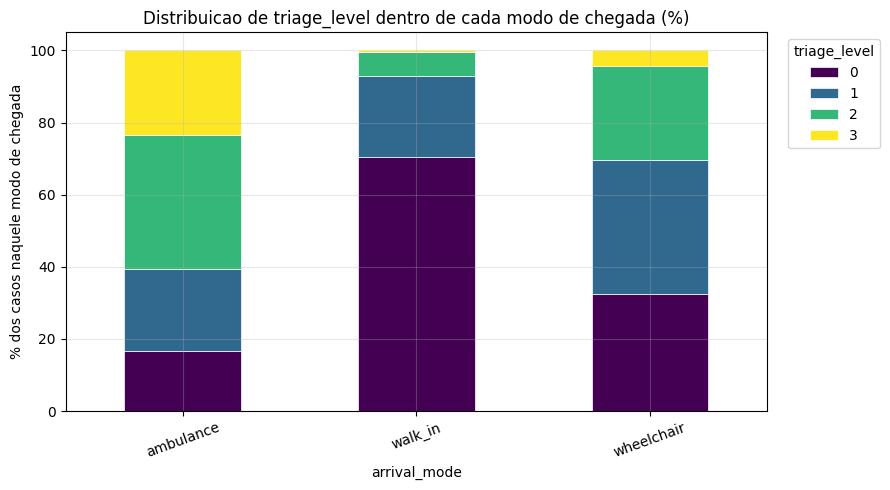

In [78]:
ct = pd.crosstab(df["arrival_mode"], df["triage_level"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(9, 5))
ct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", edgecolor="white", linewidth=0.5)
ax.set_title("Distribuicao de triage_level dentro de cada modo de chegada (%)")
ax.set_xlabel("arrival_mode")
ax.set_ylabel("% dos casos naquele modo de chegada")
ax.legend(title="triage_level", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### 11.4) Pergunta: o nivel de dor aumenta sistematicamente com o triage_level?

O histograma de `pain_level` (secao 10.4) e o scatter com FC (10.6) nao mostram diretamente a **distribuicao da dor em cada classe**; o boxplot responde isso num unico olhar.

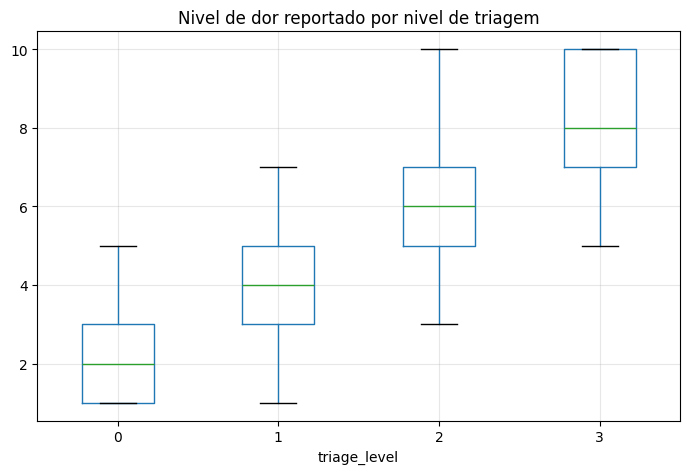

In [79]:
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column="pain_level", by="triage_level", ax=ax)
ax.set_title("Nivel de dor reportado por nivel de triagem")
ax.set_xlabel("triage_level")
plt.suptitle("")
plt.tight_layout()
plt.show()

### 11.5) Pergunta: a mistura de gravidades e semelhante entre faixas etarias?

Particionamos a idade em faixas e mostramos, **em cada faixa**, que proporcao de casos cai em cada `triage_level`. Isso ajuda a detectar envies etario na amostra antes de treinar ou interpretar um classificador.

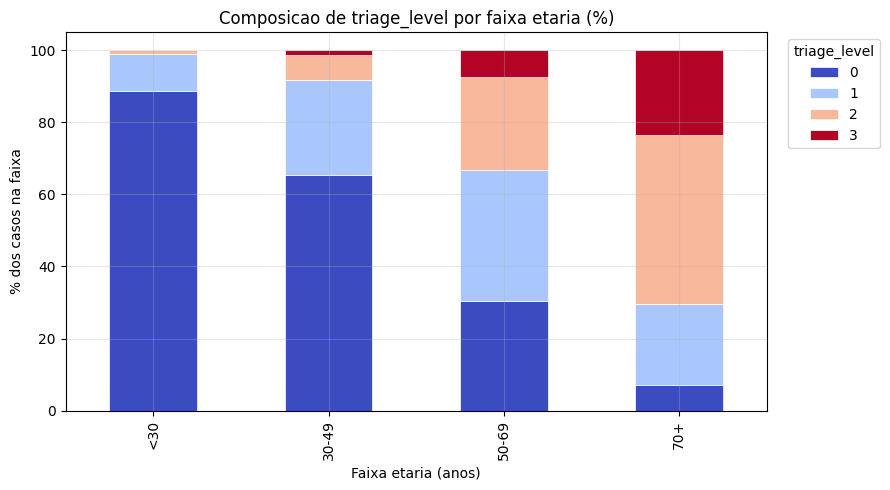

In [80]:
age_group = pd.cut(
    df["age"],
    bins=[0, 30, 50, 70, 200],
    labels=["<30", "30-49", "50-69", "70+"],
    include_lowest=True,
)
ct_age = pd.crosstab(age_group, df["triage_level"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(9, 5))
ct_age.plot(kind="bar", stacked=True, ax=ax, colormap="coolwarm", edgecolor="white", linewidth=0.5)
ax.set_title("Composicao de triage_level por faixa etaria (%)")
ax.set_xlabel("Faixa etaria (anos)")
ax.set_ylabel("% dos casos na faixa")
ax.legend(title="triage_level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 11.6) Encoding da coluna `arrival_mode`

Como este campo é importante e deve ser levado em consideração, foi necessário tratá-lo para que o modelo o compreenda.


In [81]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

mapping = {'walk_in': 0, 'wheelchair': 1, 'ambulance': 2}
df['arrival_mode_label_encoding'] = df['arrival_mode'].map(mapping)

df.head()


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level,arrival_mode_label_encoding
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3,2
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1,0
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1,0
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0,0


### 11.7) Padronização do `oxygen_saturation`

TODO: descrever o tratamento aplicado à coluna `oxygen_saturation`.


### 11.8) Gráfico de distribuição por nível de triagem e modo de chegada

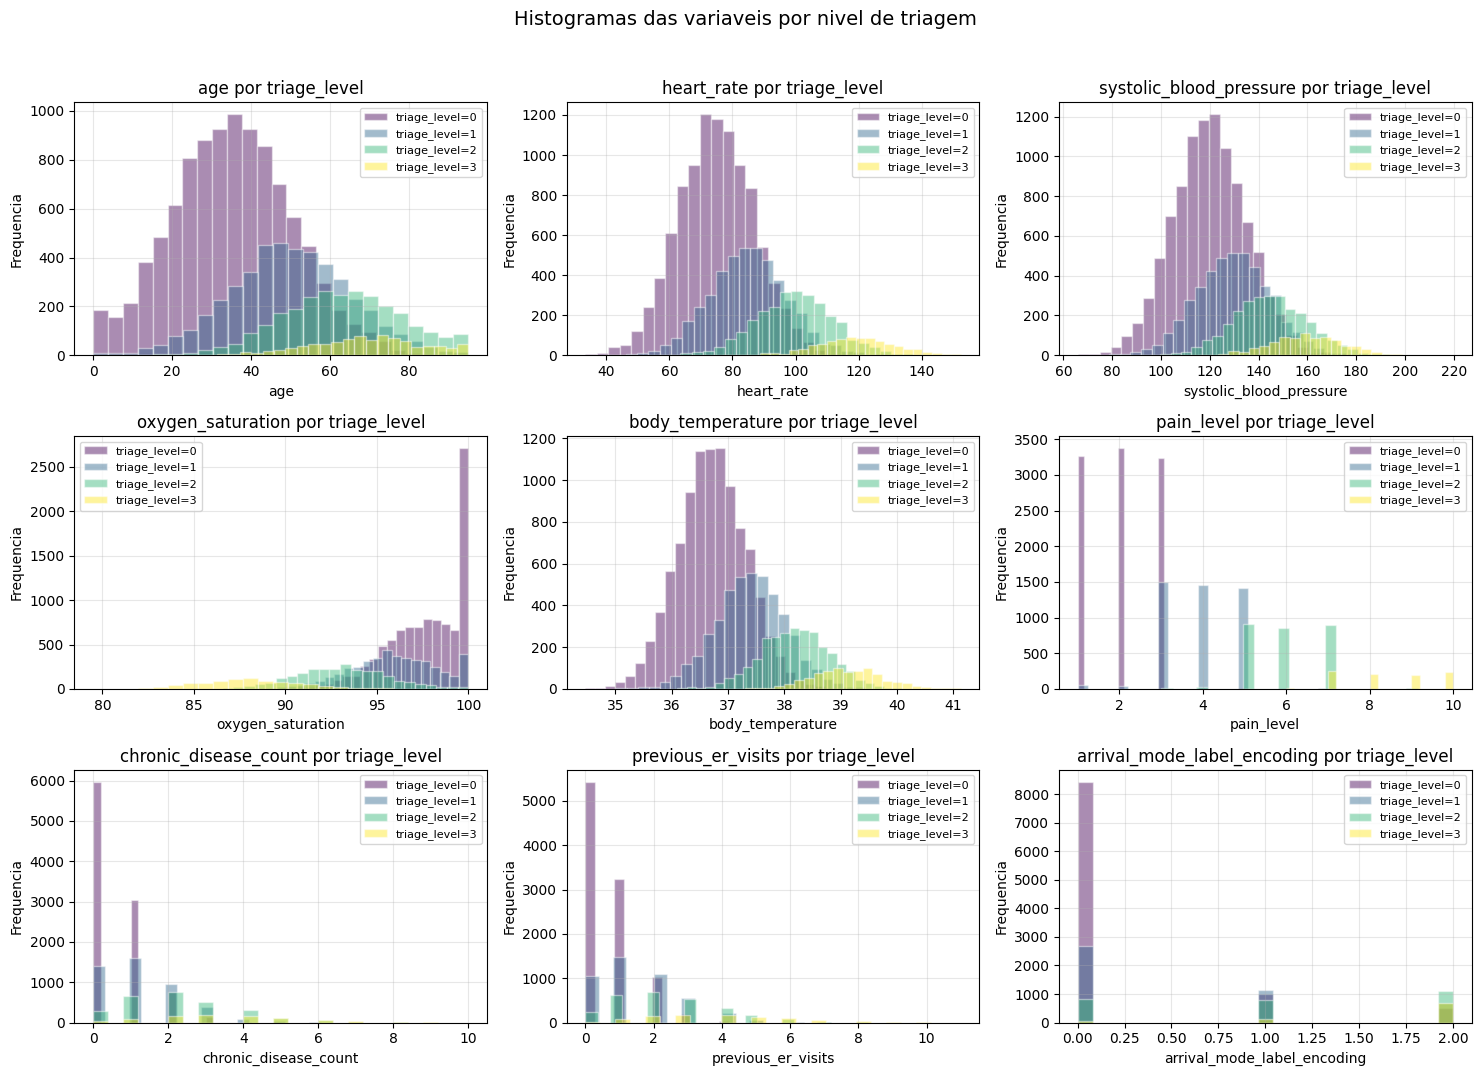

In [82]:
import matplotlib.pyplot as plt

TARGET = "triage_level"

features = [c for c in df.select_dtypes(include=["number"]).columns if c != TARGET]

n = len(features)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols

niveis = sorted(df[TARGET].dropna().unique())
cmap = plt.get_cmap("viridis", len(niveis))
cores = {nivel: cmap(i) for i, nivel in enumerate(niveis)}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    for nivel in niveis:
        valores = df.loc[df[TARGET] == nivel, col].dropna()
        if len(valores) == 0:
            continue
        ax.hist(
            valores,
            bins=25,
            alpha=0.45,
            label=f"triage_level={nivel}",
            color=cores[nivel],
            edgecolor="white",
        )
    ax.set_title(f"{col} por triage_level")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequencia")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histogramas das variaveis por nivel de triagem", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Modelo Decision Tree

In [83]:
# Separando em treino e teste
from sklearn.model_selection import train_test_split

# tirando arrival_mode por que foi criada a arrival_mode_label_encoding
x = df.drop(columns=['triage_level', 'arrival_mode'])
y = df['triage_level'] 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=7) 

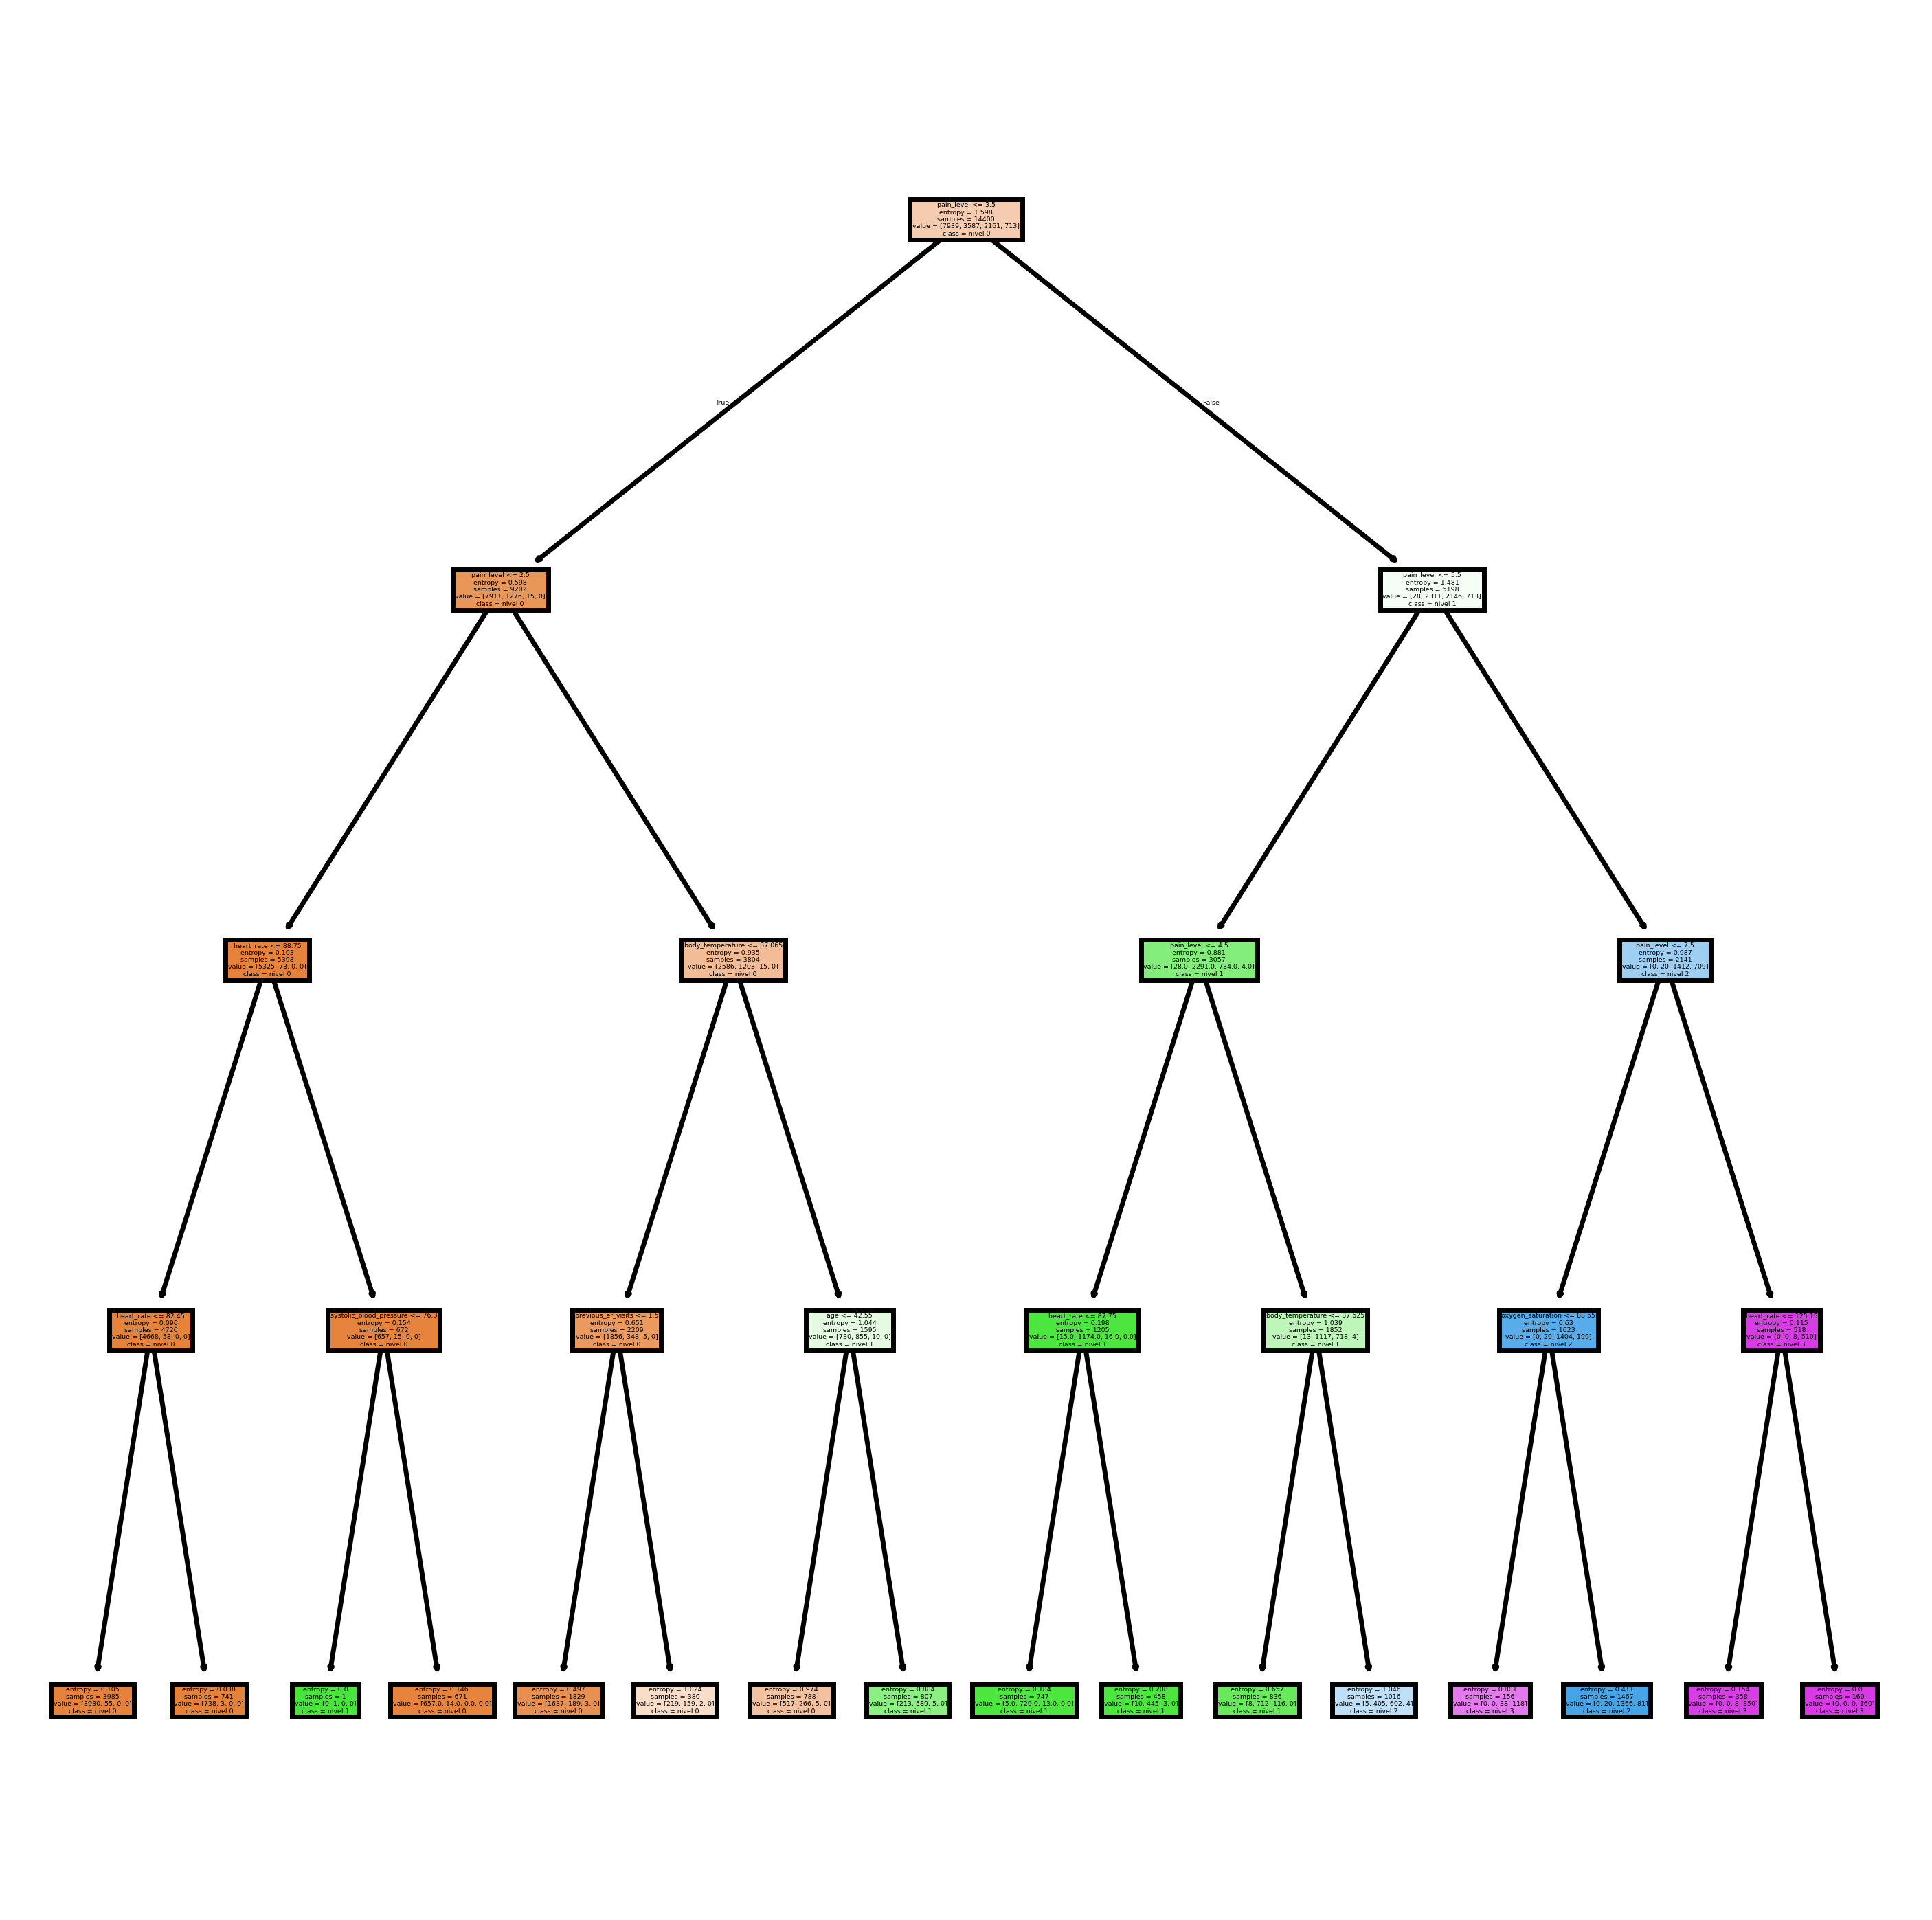

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score 


#Criando o modelo de árvore de decisão:
dt = DecisionTreeClassifier(random_state=7, criterion='entropy', max_depth = 4)
dt.fit(x_train, y_train)
y_predito = dt.predict(x_test)

#Plotando a árvore:
class_names = ["nivel 0", "nivel 1", "nivel 2", "nivel 3"]
label_names = ['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation', 'body_temperature', 'pain_level', 'chronic_disease_count', 'previous_er_visits', 'arrival_mode']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (7,7), dpi=500)


tree.plot_tree(dt,
            feature_names = label_names, 
            class_names=class_names,
            filled = True)

fig.savefig('imagename.png')

In [85]:
print(accuracy_score(y_test, y_predito))

0.8783333333333333


## Modelo Random Forest

 Acurácia:  0.9191666666666667
              precision    recall  f1-score   support

     nivel 0       0.97      0.94      0.95      1985
     nivel 1       0.84      0.88      0.86       897
     nivel 2       0.88      0.92      0.90       540
     nivel 3       0.88      0.94      0.91       178

    accuracy                           0.92      3600
   macro avg       0.89      0.92      0.91      3600
weighted avg       0.92      0.92      0.92      3600

0.9563547046227484
0.9191666666666667


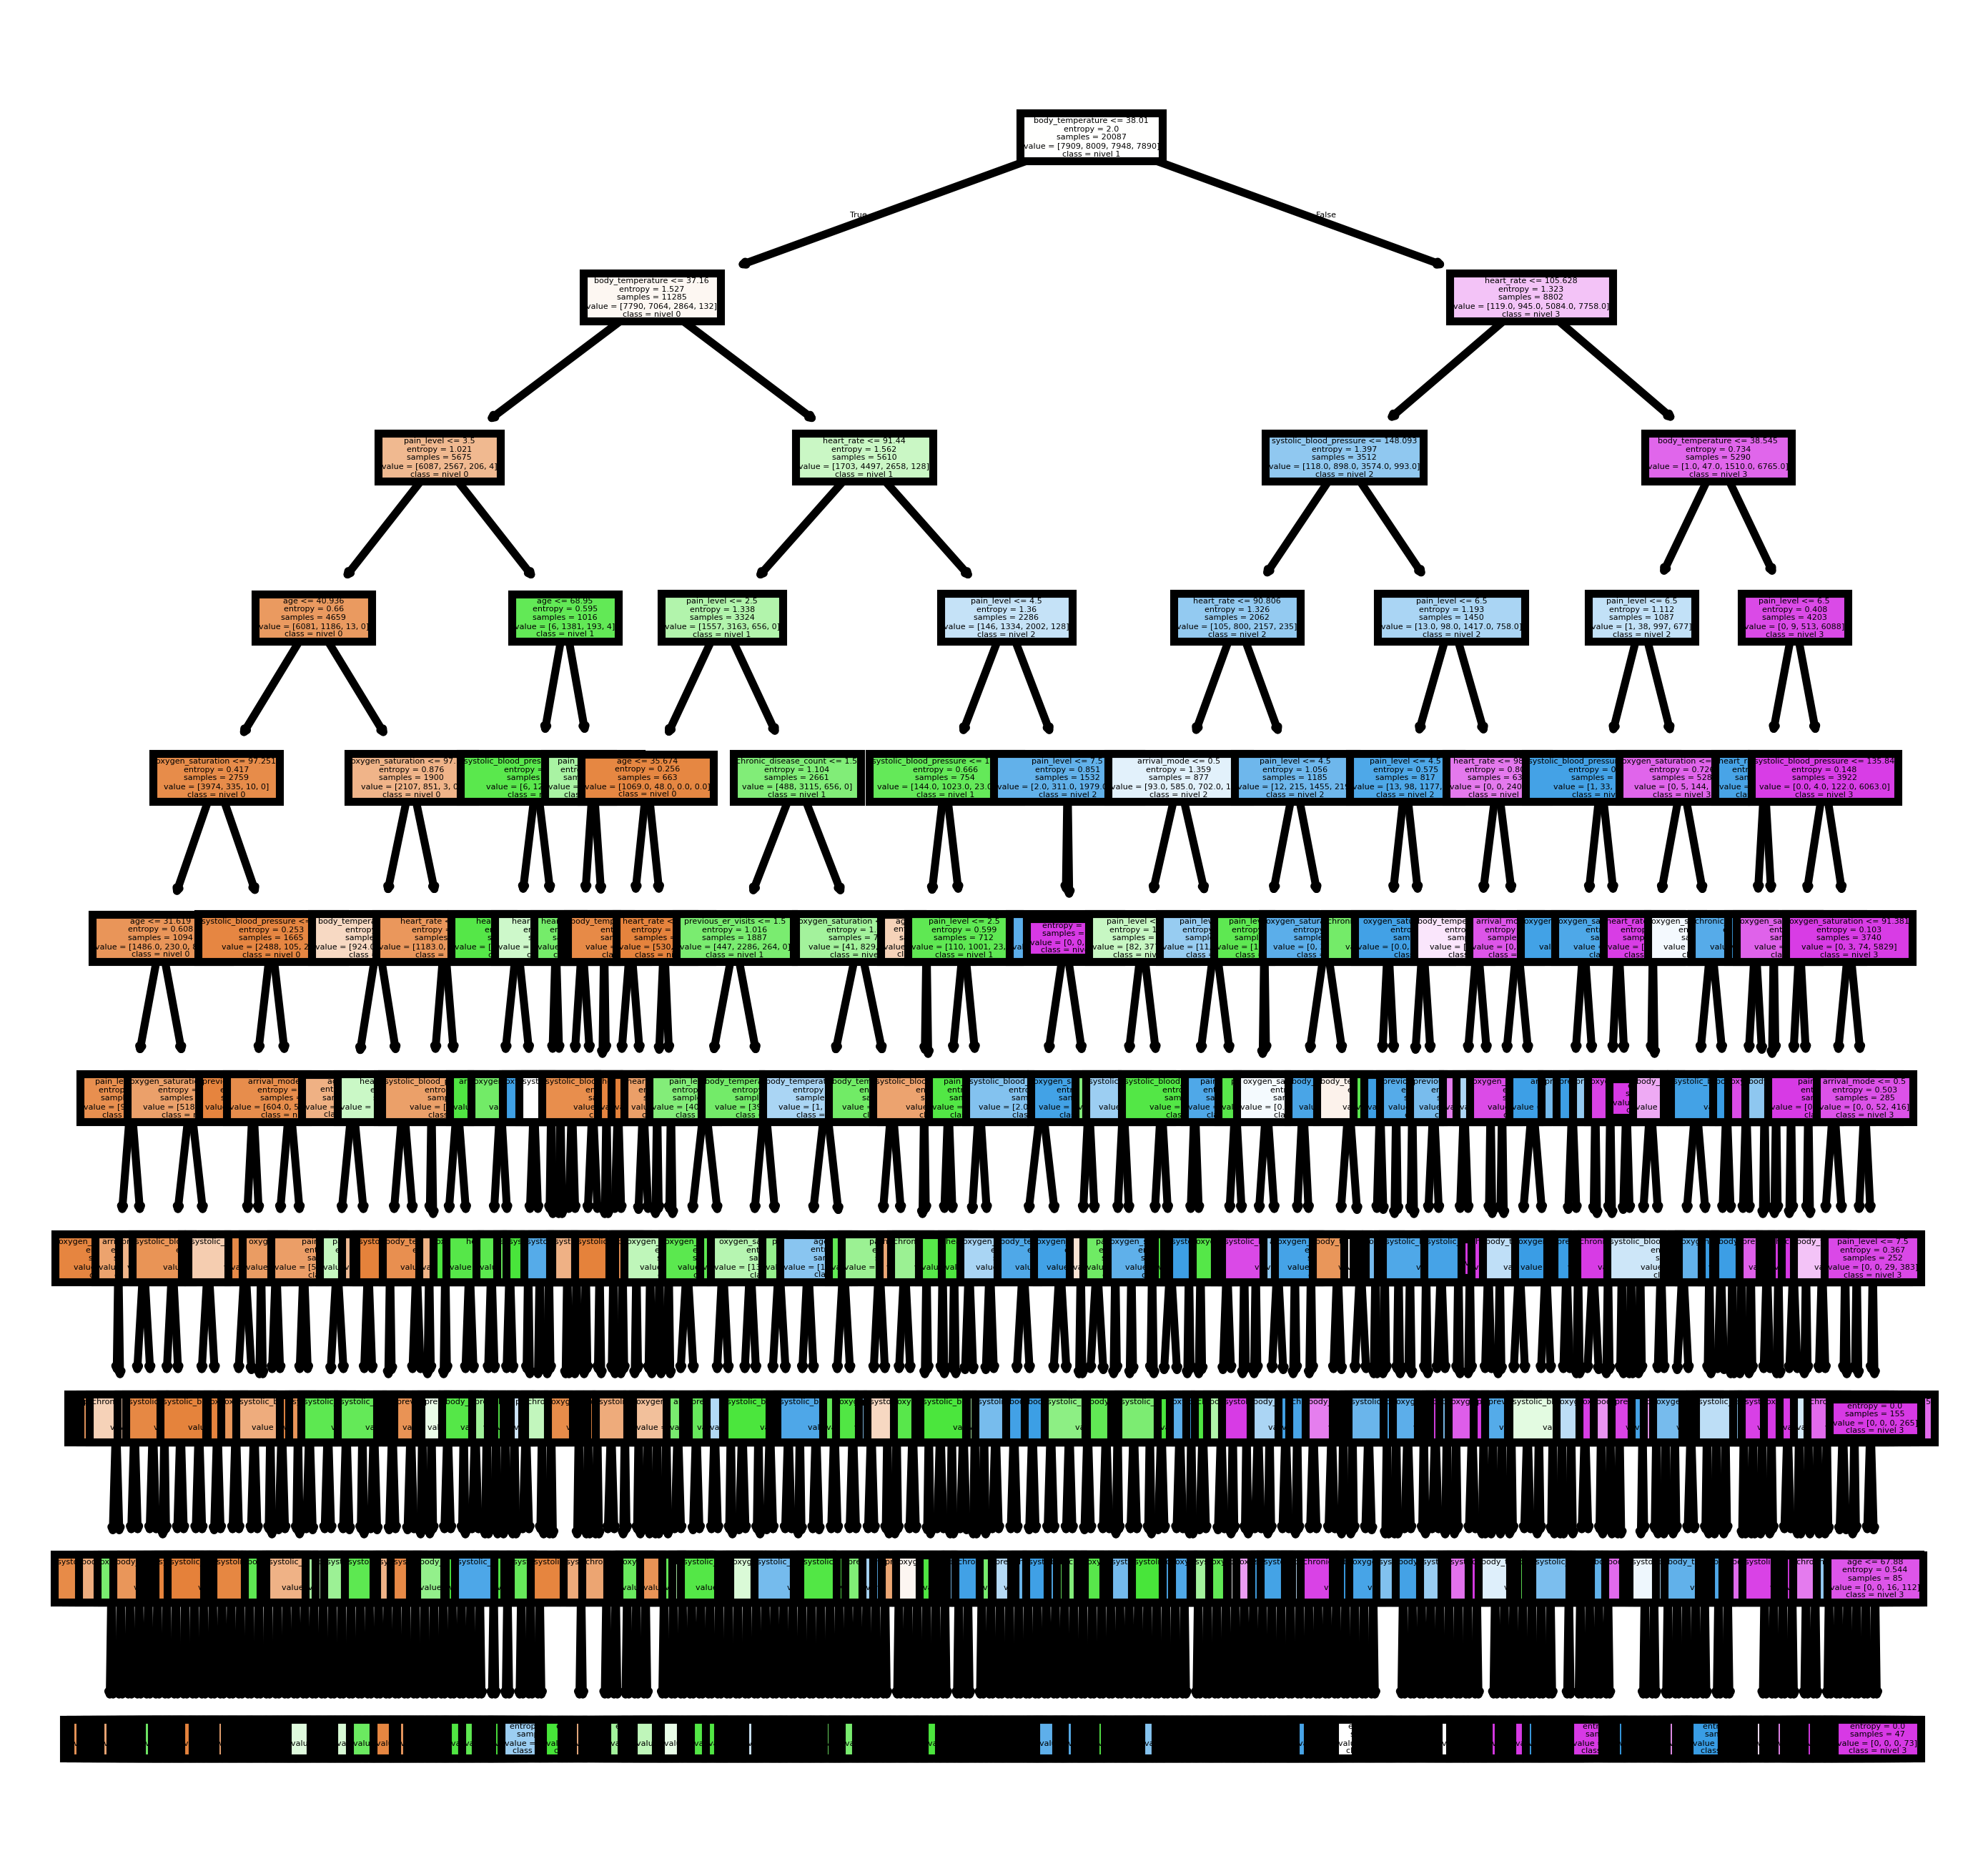

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE

oversample = SMOTE()
x_train_os, y_train_os = oversample.fit_resample(x_train, y_train)

rf = RandomForestClassifier(n_estimators=20, criterion='entropy', max_depth = 10, random_state=7, class_weight='balanced') 

rf.fit(x_train_os, y_train_os) 

estimator = rf.estimators_

y_predito_random_forest = rf.predict(x_test) 

# Metricas de precisão, revocação, f1-score e acurácia.
print(" Acurácia: ", accuracy_score(y_test, y_predito_random_forest)) #relatório com métricas
print(classification_report(y_test, y_predito_random_forest, target_names=class_names))


print(rf.score(x_train_os, y_train_os)) 
print(rf.score(x_test, y_test)) 
     

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
tree.plot_tree(rf.estimators_[0],
               feature_names = label_names, 
               class_names=class_names,
               filled = True)

fig.savefig('rf_individualtree.png')

In [87]:
print(y_test.shape)


(3600,)


In [88]:
rf.predict([[38, 91, 158.6, 100, 37.35, 4, 0, 0, 2]])


c:\Users\Kelvin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

## 12) Pipeline formal, interpretabilidade e uso prático

Nesta seção final, consolidamos os requisitos pendentes do trabalho com uma estrutura **reprodutível** e **auditável**:

1. limpeza de dados documentada (regras, inconsistências e estratégia);
2. pipeline formal com `ColumnTransformer` + `Pipeline`;
3. treinamento e avaliação com foco em métricas clínicas;
4. interpretabilidade com `feature importance` e **SHAP**;
5. discussão crítica de uso em prática clínica.

### 12.1) Limpeza de dados documentada (estratégia aplicada)

**Estratégia adotada**
- **Duplicados:** remover linhas duplicadas para evitar contagem dupla de pacientes.
- **Tipos e padronização:** garantir tipos numéricos e padronizar texto de categóricas (`strip/lower`).
- **Regras de consistência clínica (conservadoras):**
  - `pain_level` limitado a [0, 10];
  - `oxygen_saturation` limitado a [0, 100];
  - `age`, `heart_rate`, `systolic_blood_pressure`, `body_temperature`, `chronic_disease_count`, `previous_er_visits` não negativos.
- **Ausentes:** não removemos registros por NA nesta etapa; o tratamento é feito no pipeline com imputação para manter reprodutibilidade entre treino e inferência.

In [89]:
import numpy as np
import pandas as pd

# Copia para modelagem reprodutível, preservando df original
clean_df = df.copy()

# 1) Remoção de duplicados
n_before = len(clean_df)
clean_df = clean_df.drop_duplicates()
removed_duplicates = n_before - len(clean_df)

# 2) Padronização de categoria textual
if "arrival_mode" in clean_df.columns:
    clean_df["arrival_mode"] = (
        clean_df["arrival_mode"].astype("string").str.strip().str.lower()
    )

# 3) Coerção de colunas numéricas
numeric_cols_expected = [
    "age",
    "heart_rate",
    "systolic_blood_pressure",
    "oxygen_saturation",
    "body_temperature",
    "pain_level",
    "chronic_disease_count",
    "previous_er_visits",
    "triage_level",
]
for col in numeric_cols_expected:
    if col in clean_df.columns:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# 4) Regras de consistência
if "pain_level" in clean_df.columns:
    clean_df["pain_level"] = clean_df["pain_level"].clip(0, 10)
if "oxygen_saturation" in clean_df.columns:
    clean_df["oxygen_saturation"] = clean_df["oxygen_saturation"].clip(0, 100)

for col in [
    "age",
    "heart_rate",
    "systolic_blood_pressure",
    "body_temperature",
    "chronic_disease_count",
    "previous_er_visits",
]:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].clip(lower=0)

# 5) Relatório de limpeza
na_report = clean_df.isna().sum().sort_values(ascending=False)
print(f"Registros removidos por duplicidade: {removed_duplicates}")
print("\nValores ausentes após padronização/coerção:")
display(na_report.to_frame("missing_count"))

print("\nAmostra após limpeza:")
display(clean_df.head())

Registros removidos por duplicidade: 0

Valores ausentes após padronização/coerção:


,missing_count
age,0
heart_rate,0
systolic_blood_pressure,0
oxygen_saturation,0
body_temperature,0
pain_level,0
chronic_disease_count,0
previous_er_visits,0
arrival_mode,0
triage_level,0



Amostra após limpeza:


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level,arrival_mode_label_encoding
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3,2
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1,0
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1,0
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0,0


### 12.2) Pipeline formal com `ColumnTransformer` + `Pipeline`

Abaixo construímos um fluxo único e reprodutível para treino e inferência:

- **numéricas:** imputação por mediana + padronização (`StandardScaler`);
- **categóricas:** imputação por moda + `OneHotEncoder`;
- **modelo:** `RandomForestClassifier` com `class_weight='balanced'`.

Esse desenho evita vazamento de dados e garante que qualquer nova observação receba exatamente o mesmo pré-processamento do treino.

In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

TARGET = "triage_level"

X = clean_df.drop(columns=[TARGET])
y = clean_df[TARGET].astype(int)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=7,
                class_weight="balanced",
                n_jobs=-1,
            ),
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=7,
)

rf_pipeline.fit(X_train, y_train)
print("Pipeline treinado com sucesso.")
print(f"Features numéricas: {numeric_features}")
print(f"Features categóricas: {categorical_features}")

Pipeline treinado com sucesso.
Features numéricas: ['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation', 'body_temperature', 'pain_level', 'chronic_disease_count', 'previous_er_visits', 'arrival_mode_label_encoding']
Features categóricas: ['arrival_mode']


### 12.3) Avaliação e justificativa de métricas para saúde

Em triagem clínica, **falso negativo** (subestimar gravidade) é especialmente crítico. Por isso:

- reportamos `accuracy`, mas não usamos como métrica principal isolada;
- destacamos `recall` e `F1` (macro/weighted) para capturar sensibilidade e equilíbrio entre precisão e cobertura das classes;
- adicionalmente, avaliamos um cenário operacional binário: **alto risco** (`triage_level >= 2`) vs demais, para medir sensibilidade clínica direta em casos graves.

Accuracy:     0.9450
Recall macro: 0.9282
F1 macro:     0.9337
F1 weighted:  0.9446

Relatório por classe:
              precision    recall  f1-score   support

           0     0.9591    0.9798    0.9693      1985
           1     0.9198    0.8818    0.9004       897
           2     0.9314    0.9296    0.9305       540
           3     0.9480    0.9213    0.9345       178

    accuracy                         0.9450      3600
   macro avg     0.9395    0.9282    0.9337      3600
weighted avg     0.9446    0.9450    0.9446      3600



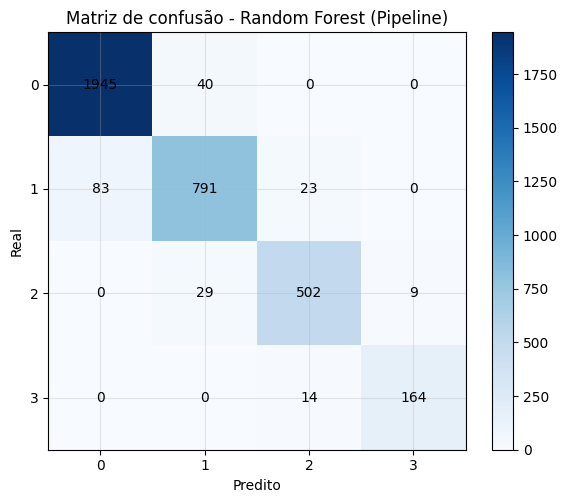


Cenário binário clínico (alto risco >=2):
Recall alto risco: 0.9596
F1 alto risco:     0.9636


In [91]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
import matplotlib.pyplot as plt

y_pred = rf_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy:     {acc:.4f}")
print(f"Recall macro: {recall_macro:.4f}")
print(f"F1 macro:     {f1_macro:.4f}")
print(f"F1 weighted:  {f1_weighted:.4f}")
print("\nRelatório por classe:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Matriz de confusão - Random Forest (Pipeline)")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_xticks(range(len(np.unique(y_test))))
ax.set_yticks(range(len(np.unique(y_test))))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Cenário operacional: alto risco (2 e 3) versus não alto risco (0 e 1)
y_test_high_risk = (y_test >= 2).astype(int)
y_pred_high_risk = (y_pred >= 2).astype(int)

recall_high_risk = recall_score(y_test_high_risk, y_pred_high_risk)
f1_high_risk = f1_score(y_test_high_risk, y_pred_high_risk)

print("\nCenário binário clínico (alto risco >=2):")
print(f"Recall alto risco: {recall_high_risk:.4f}")
print(f"F1 alto risco:     {f1_high_risk:.4f}")

### 12.4) Interpretabilidade: feature importance (global)

Para explicar o comportamento global do modelo, extraímos as importâncias de variáveis da Random Forest treinada no pipeline. Como há one-hot nas categóricas, também recuperamos os nomes expandidos das features.

Top 15 variáveis mais importantes:


,feature,importance
0,num__pain_level,0.350963
1,num__oxygen_saturation,0.148564
2,num__body_temperature,0.145783
3,num__heart_rate,0.122964
4,num__systolic_blood_pressure,0.066431
5,num__age,0.064732
6,num__previous_er_visits,0.032959
7,num__chronic_disease_count,0.025442
8,num__arrival_mode_label_encoding,0.018625
9,cat__arrival_mode_walk_in,0.013358


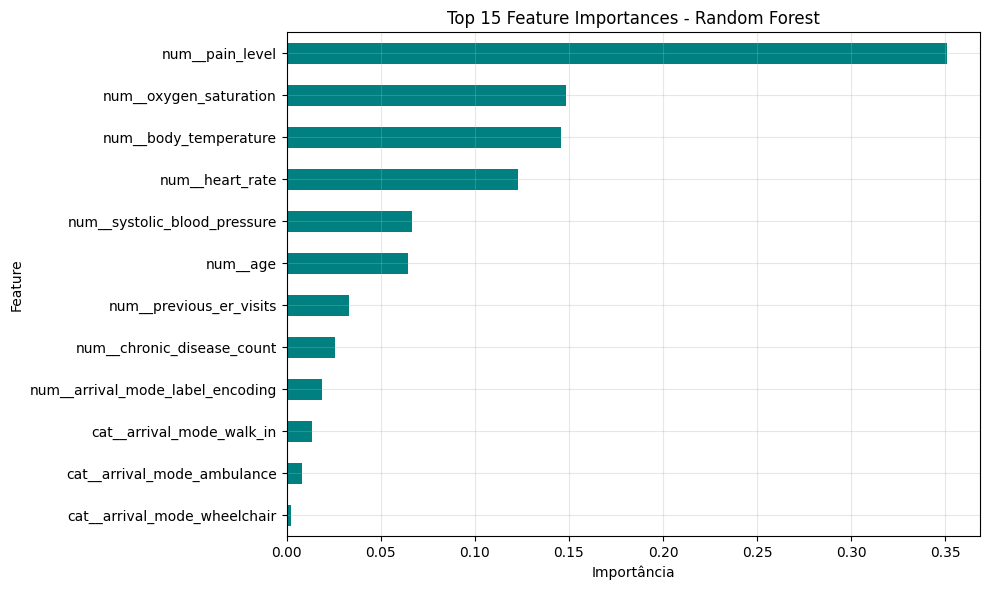

In [92]:
# Recupera nomes das features após preprocessamento
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

fi = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 variáveis mais importantes:")
display(fi.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
fi.head(15).sort_values("importance").plot(
    kind="barh", x="feature", y="importance", ax=ax, color="teal", legend=False
)
ax.set_title("Top 15 Feature Importances - Random Forest")
ax.set_xlabel("Importância")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### 12.5) Interpretabilidade local e global com SHAP

SHAP complementa a importância global mostrando:
- impacto das features na predição global (`summary_plot`);
- contribuição por instância (quais variáveis puxaram o score para cima/baixo).

> Observação: se `shap` não estiver instalado no ambiente, instale com `%pip install shap` e execute novamente.

In [94]:
# SHAP com modelo de árvore já treinado dentro do Pipeline
try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP não disponível no ambiente.")
    print("Instale via: %pip install shap")
    print(f"Detalhe: {e}")

if SHAP_AVAILABLE:
    # Amostra para reduzir custo computacional e manter notebook responsivo
    sample_n = min(1200, len(X_test))
    X_test_sample = X_test.sample(sample_n, random_state=7)

    # Transforma X no mesmo espaço usado pelo modelo
    X_test_trans = rf_pipeline.named_steps["preprocessor"].transform(X_test_sample)
    model_rf = rf_pipeline.named_steps["model"]

    explainer = shap.TreeExplainer(model_rf)
    shap_values = explainer.shap_values(X_test_trans)

    # SHAP multiclasses pode retornar lista (1 array por classe)
    if isinstance(shap_values, list):
        class_idx = len(shap_values) - 1  # classe de maior gravidade
        shap_to_plot = shap_values[class_idx]
        class_label = f"classe {class_idx}"
    else:
        shap_to_plot = shap_values
        class_label = "saída do modelo"

    print(f"Gerando summary plot SHAP para {class_label}...")
    shap.summary_plot(
        shap_to_plot,
        X_test_trans,
        feature_names=feature_names,
        max_display=15,
        show=True,
    )

    # Explicação local de um caso
    idx_local = 0
    if isinstance(shap_values, list):
        shap_local = shap_values[class_idx][idx_local]
        expected_value_local = explainer.expected_value[class_idx]
    else:
        shap_local = shap_values[idx_local]
        expected_value_local = explainer.expected_value

    shap.plots.force(
        expected_value_local,
        shap_local,
        feature_names=feature_names,
        matplotlib=True,
        show=True,
    )

SHAP não disponível no ambiente.
Instale via: %pip install shap
Detalhe: No module named 'shap'


### 12.6) Discussão crítica de uso prático (resposta direta ao enunciado)

**O modelo pode ser usado na prática?**
- **Como apoio à decisão clínica (triagem assistida)**, priorizando fila e alertando casos com probabilidade de maior gravidade.
- **Não** deve ser usado como decisão autônoma diagnóstica.

**Em que contexto?**
- triagem em pronto atendimento, com integração ao fluxo de recepção/enfermagem;
- uso em tempo real para priorização de atendimento e monitoramento de risco.

**Principais riscos e limitações**
- base utilizada é **sintética**, podendo não refletir toda a variabilidade clínica real;
- risco de viés por distribuição de classes, faixa etária e modo de chegada;
- desempenho pode cair em hospitais/populações diferentes sem recalibração;
- sensibilidade a mudanças de protocolo clínico ao longo do tempo (drift).

**Validação necessária antes de produção**
- validação externa em dados reais multicêntricos;
- avaliação prospectiva (piloto assistido) com monitoramento contínuo;
- definição de limiares clínicos com equipe médica e governança de risco.

**Papel final do médico**
- a predição é um **sinal de suporte**;
- o(a) médico(a) mantém a decisão final diagnóstica e terapêutica, considerando contexto clínico completo, exame físico e julgamento profissional.